In [1]:
%matplotlib widget
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [36]:
dir_scaling = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/data/scaling_airglow/'
models = ['Cold100', 'Hot40', 'Hot25', 'Hot10']
#models = ['Cold100',]

airglow = pd.DataFrame()
for model in models:
    file = f'{dir_scaling}dayglow_scaler_{model}.csv'
    dayglow_scaling = pd.read_csv(file)
    for col in dayglow_scaling.columns:
        if col in ['f1', 'f2']:
            continue
        dayglow_scaling.loc[:,col] /= 1e2 # conversion % to factor
    file = f'{dir_scaling}nightglow_scaler_{model}.csv'
    nightglow_scaling = pd.read_csv(file)
    for col in nightglow_scaling.columns:
        if col in ['f1', 'f2']:
            continue
        nightglow_scaling.loc[:,col] /= 1e2 # conversion % to factor
    airglow_loc = pd.concat([dayglow_scaling, nightglow_scaling.loc[:,~nightglow_scaling.columns.isin(['f1', 'f2'])]], axis=1)
    airglow_loc['store'] = model
    airglow = pd.concat([airglow, airglow_loc])
    airglow_loc.to_csv(f'{dir_scaling}data_airglow_scaling_{model}.csv', header=True, index=False)

In [5]:
dir_scaling = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/data/scaling_airglow/'
file = f'{dir_scaling}data_airglow_scaling_freqscaled.csv'
airglow = pd.read_csv(file)

In [2]:
from scipy import interpolate
file_atmos = '/staff/quentin/Documents/Projects/2024_Venus_Detectability/Venus_Detectability/data/profile_VCD_for_scaling_pd.csv'
profile = pd.read_csv(file_atmos)
f_rho = interpolate.interp1d(profile.altitude/1e3, profile.rho, kind='quadratic')
f_t = interpolate.interp1d(profile.altitude/1e3, profile.t, kind='quadratic')
f_p = interpolate.interp1d(profile.altitude/1e3, profile.p, kind='quadratic')
f_gamma = interpolate.interp1d(profile.altitude/1e3, profile.gamma, kind='quadratic')
f_c = interpolate.interp1d(profile.altitude/1e3, profile.c, kind='quadratic')

In [3]:
def get_raphael_factor_dayglow():

    z_IR = 135. # dayglow
    sensitivity = 1e-2
    factor_T = sensitivity*((f_gamma(z_IR)-1.)/f_gamma(z_IR))*f_t(z_IR)/f_p(z_IR)
    ampl_vel = np.sqrt((f_rho(0.)*f_c(0.))/(f_rho(z_IR)*f_c(z_IR)))
    factor_P = f_rho(z_IR)*f_c(z_IR)*ampl_vel
    print(f'ampl_vel: {ampl_vel}')
    print(f'factor_P: {factor_P}')

    return factor_P*factor_T

def get_raphael_factor_nightglow():

    z_IR = 100. # nightglow
    sensitivity = 3e-2
    factor_v = sensitivity*np.sqrt((f_rho(0.)*f_c(0.))/(f_rho(z_IR)*f_c(z_IR)))
    
    return factor_v

factor_dayglow = get_raphael_factor_dayglow(),
factor_nightglow = get_raphael_factor_nightglow()

ampl_vel: 215130.843881071
factor_P: 0.1294737165787263


NameError: name 'airglow' is not defined

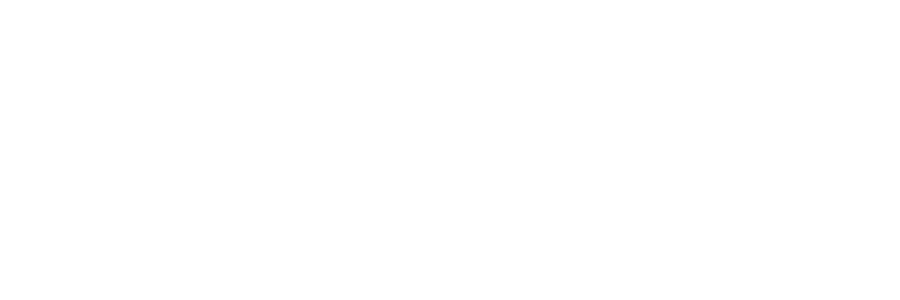

In [4]:
fig = plt.figure(figsize=(9,3))
grid = fig.add_gridspec(1, 4)

for imodel, (model, airglow_model) in enumerate(airglow.groupby('store')):
    opt_ax = dict()
    if imodel > 0:
        opt_ax = dict(sharex=ax, sharey=ax)
    ax = fig.add_subplot(grid[0, imodel], **opt_ax)
    ax.plot(0.5*(airglow_model.f1+airglow_model.f2), airglow_model.dayglow, color='tab:orange', lw=4, marker='o')
    ax.plot(0.5*(airglow_model.f1+airglow_model.f2), airglow_model.nightglow, color='tab:blue', lw=4, marker='o')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title('')
    if imodel == 0:
        ax.set_ylabel('Scaling factor')
    else:
        ax.tick_params(axis='both', which='both', labelleft=False)
fig.subplots_adjust(bottom=0.2)

In [31]:
fac_Npm_dBkm = 20*np.log10(np.e)*1000
alpha_dBkm = 1e-0
alpha_Npm = alpha_dBkm/fac_Npm_dBkm
alpha_dBkm, alpha_Npm

(1.0, 0.00011512925464970229)

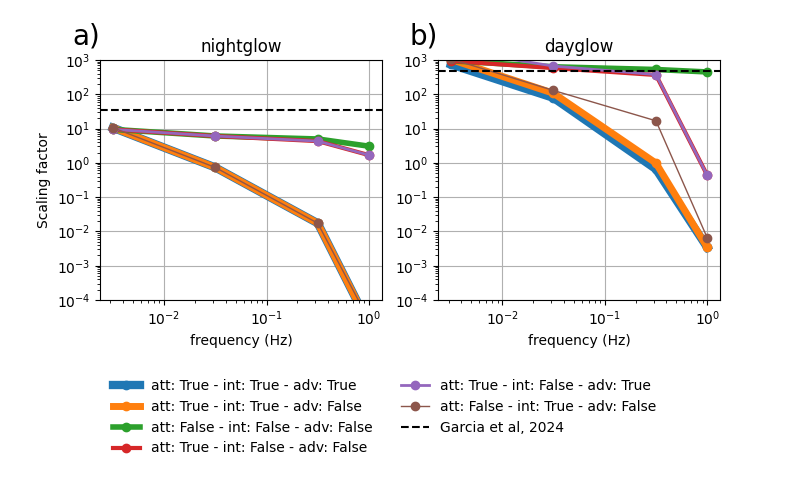

In [10]:
import string
alphabet = string.ascii_lowercase
dir_scaling = '/staff/quentin/Documents/Projects/2025_airglow_response/airglow_model/results_detectability/'

scenarios = [dict(disable_att=False, disable_int=False, disable_adv=False),
             dict(disable_att=False, disable_int=False, disable_adv=True),
             dict(disable_att=True, disable_int=True, disable_adv=True),
            dict(disable_att=False, disable_int=True, disable_adv=True),
            dict(disable_att=False, disable_int=True, disable_adv=False),
            dict(disable_att=True, disable_int=False, disable_adv=True)]

fig = plt.figure(figsize=(8,5))
grid = fig.add_gridspec(1, 2)

iairglow = -1
for airglow in ['nightglow', 'dayglow']:
    iairglow += 1
    opt_ax = dict() if iairglow == 0 else dict(sharex=ax, sharey=ax)
    ax = fig.add_subplot(grid[0, iairglow], **opt_ax)
    iscenario = len(scenarios)
    for opt_disable in scenarios:
        disable_att = opt_disable['disable_att']
        disable_int = opt_disable['disable_int']
        disable_adv = opt_disable['disable_adv']
        file = f'{airglow}_scaleratt{disable_att}_int{disable_int}_adv{disable_adv}_new_ampli.csv'
        scaling = pd.read_csv(f'{dir_scaling}{file}')
        ax.plot(scaling.f2, scaling[airglow]/1e2, lw=iscenario, label=f'att: {not disable_att} - int: {not disable_int} - adv: {not disable_adv}', marker='o')
        ax.set_yscale('log')
        ax.set_xscale('log')
        iscenario -= 1
    
    if airglow == 'nightglow':
        ax.axhline(factor_nightglow, color='black', ls='--', label='Garcia et al, 2024')
        
    if airglow == 'dayglow':
        ax.axhline(factor_dayglow, color='black', ls='--', label='Garcia et al, 2024')
        
    if iairglow == 0:
        ax.legend(ncol=2, loc='lower left', bbox_to_anchor=(0., -0.7), bbox_transform=ax.transAxes, frameon=False)
        ax.set_ylabel('Scaling factor')
    ax.set_title(airglow)
    ax.grid()
    ax.set_xlabel('frequency (Hz)')
    ax.text(-0., 1.04, f'{alphabet[iairglow]})', fontsize=20., ha='right', va='bottom', transform=ax.transAxes)
    
    ax.set_ylim([1e-4, 1e3])
    
fig.subplots_adjust(bottom=0.4)
fig.savefig('./figures/Figure_comparison_scaler_airglow_new.pdf')

In [125]:
alts = np.arange(90., 150., 5)
times = np.arange(0., 600., 1.)
c = 0.3
alpha = 1e-2
amplification = 1250.*np.exp(-((alts-145.)/10.)**2)
VER = (3.e-7)*np.exp(-((alts-138.)/15.)**2)
VER_dz = -2*(1./15.)*((alts-138.)/15.)*(3.e-7)*np.exp(-((alts-138.)/15.)**2)
periods = [5., 15., 30.]

factor = []
for period in periods:
    signal_dt = lambda times: -2*(1./period)*((times-20.)/period)*np.exp(-((times-20.)/period)**2) 
    signal = lambda times: np.exp(-((times-20.)/period)**2) 

    uz = alpha*(1.-f_gamma(alts[None,:]))*f_t(alts[None,:])*amplification[None,:]*signal_dt(times[:,None]-(alts[None,:]-alts.min())/c)
    uz_int = np.trapz(VER[None,:]*uz, x=alts*1e3, axis=1)/np.trapz(VER, x=alts*1e3)
    
    factor.append(abs(uz_int).max()/abs(uz).max())

"""
plt.figure()
for ii in [0, 20, 40]:
    plt.plot(times, uz[:,ii])

plt.figure()
plt.plot(times, uz_int)
#plt.plot(VER, alts)

plt.figure()
plt.plot(times, uz[:,np.argmin(abs(alts-135.))])
"""

'\nplt.figure()\nfor ii in [0, 20, 40]:\n    plt.plot(times, uz[:,ii])\n\nplt.figure()\nplt.plot(times, uz_int)\n#plt.plot(VER, alts)\n\nplt.figure()\nplt.plot(times, uz[:,np.argmin(abs(alts-135.))])\n'

In [126]:
[f'{period} s: {fac}' for period, fac in zip(periods, factor)]

['5.0 s: 0.1788871518157247',
 '15.0 s: 0.14665029442621694',
 '30.0 s: 0.27406931945210816']

In [116]:
[f'{period} s: {fac}' for period, fac in zip(periods, factor)]

['5.0 s: 0.1788871518157247',
 '15.0 s: 0.14665029442621694',
 '30.0 s: 0.27406931945210816']